# Outline


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('zameen_eda_cleaned.csv',index_col=0)

In [3]:
df.shape

(2865, 40)

In [4]:
df.columns

Index(['Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)', 'Bedroom(s)', 'Location',
       'Description', 'Amenities: Main Features', 'Amenities: Rooms',
       'Amenities: Business and Communication',
       'Amenities: Community Features', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Bedrooms', 'Bathrooms',
       'Servant Quarters', 'Kitchens', 'Store Rooms',
       'Community Swimming Pool', 'Community Gym', 'Swimming Pool', 'Sauna',
       'Jacuzzi', 'Security Staff', 'Maintenance Staff',
       'Facilities for Disabled', 'Laundry or Dry Cleaning Facility',
       'Communal/Shared Kitchen', 'Storey Unit'],
      dtype='str')

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 2865 entries, 0 to 2865
Data columns (total 40 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Type                                   2865 non-null   str    
 1   Price(Cr)                              2865 non-null   float64
 2   Bath(s)                                2813 non-null   float64
 3   Area(Marla)                            2865 non-null   float64
 4   Bedroom(s)                             2813 non-null   float64
 5   Location                               2865 non-null   str    
 6   Description                            2865 non-null   str    
 7   Amenities: Main Features               2682 non-null   str    
 8   Amenities: Rooms                       2621 non-null   str    
 9   Amenities: Business and Communication  2515 non-null   str    
 10  Amenities: Community Features          2508 non-null   str    
 11  Amenities: Healthcar

## Type vs Price

<Axes: xlabel='Type', ylabel='Price(Cr)'>

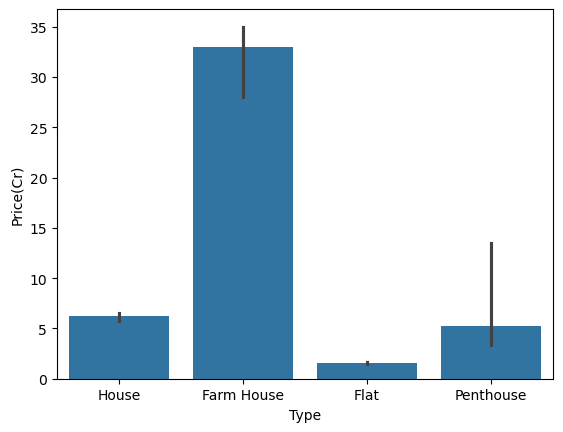

In [7]:
sns.barplot(data=df,x='Type',y='Price(Cr)',estimator=np.median)

<Axes: xlabel='Type', ylabel='Price(Cr)'>

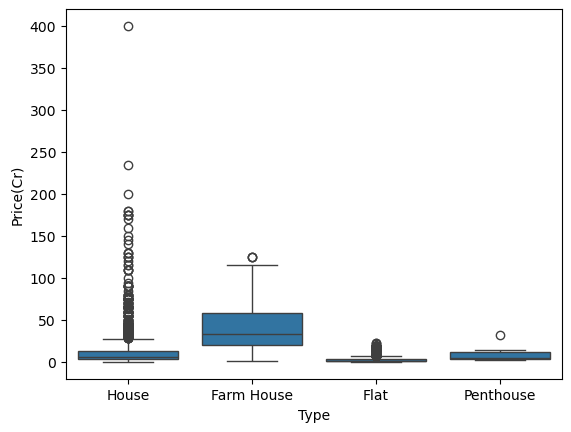

In [8]:
sns.boxplot(data=df,x='Type',y='Price(Cr)')

In [9]:
df[df['Type']=='Penthouse'].shape[0]

10

In [10]:
df[df['Type']=='Penthouse']['Price(Cr)'].mean()

np.float64(9.290000000000001)

### Observations
- The House category has a higher range having plenty of outliers.
- Flats has lower Price values as compared to others.
- Penthouse has lower median because of less number of rows.

## Area vs Price

<Axes: xlabel='Area(Marla)', ylabel='Price(Cr)'>

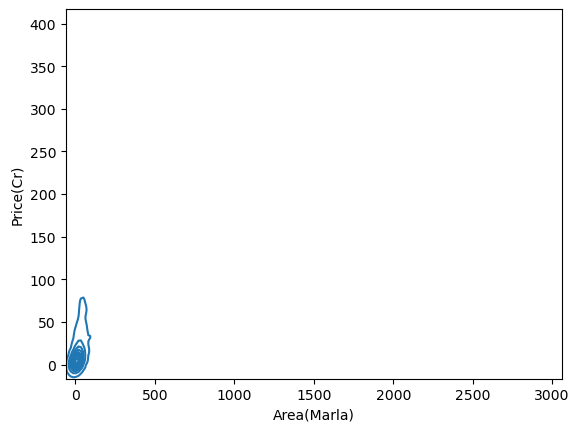

In [11]:
sns.kdeplot(data=df,x='Area(Marla)',y='Price(Cr)')

<Axes: xlabel='Area(Marla)', ylabel='Price(Cr)'>

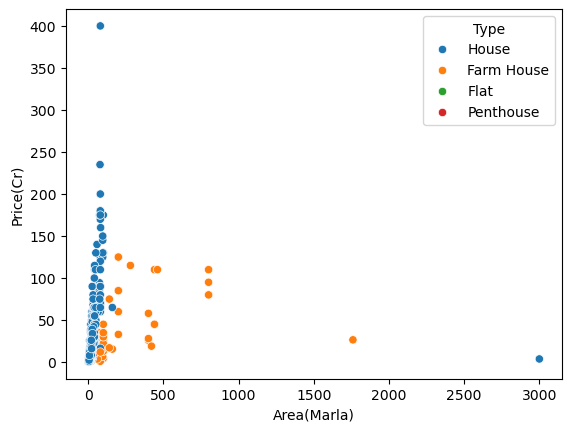

In [12]:
sns.scatterplot(data=df,x='Area(Marla)',y='Price(Cr)',hue='Type')

#### Finding Multivariate outliers using Isolation Forest and Local Outlier Factor and Visualizing it 

In [13]:
# Isolation Forest
from sklearn.ensemble import IsolationForest

clf = IsolationForest(max_samples=100,contamination='auto')
clf.fit(df[['Price(Cr)','Area(Marla)']])
y_pred = clf.predict(df[['Price(Cr)','Area(Marla)']])

In [14]:
y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(2865,))

In [15]:
pd.Series(y_pred).unique()

array([ 1, -1])

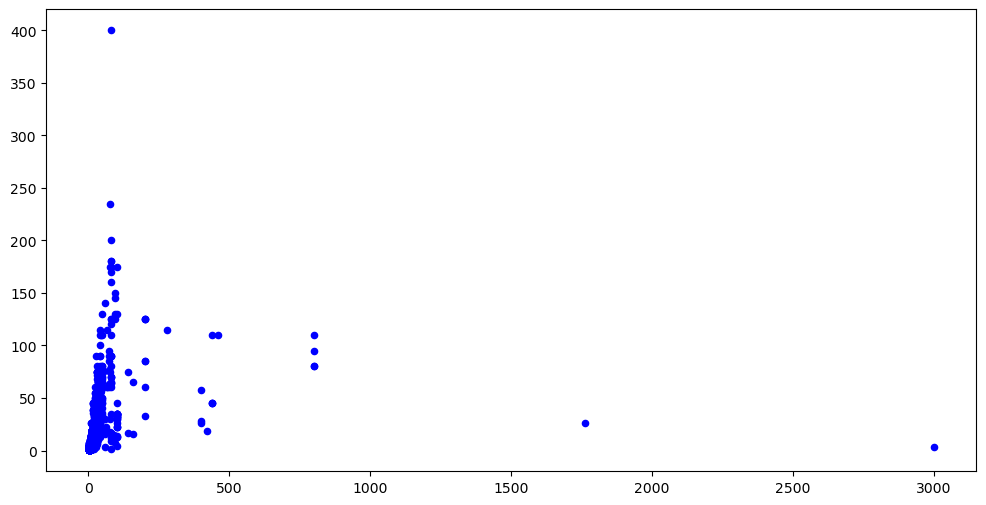

In [16]:
plt.figure(figsize=(12,6))
plt.scatter(x=df['Area(Marla)'],y=df['Price(Cr)'],s=20,color='b')

is_outlier = y_pred == -1
#plt.scatter()

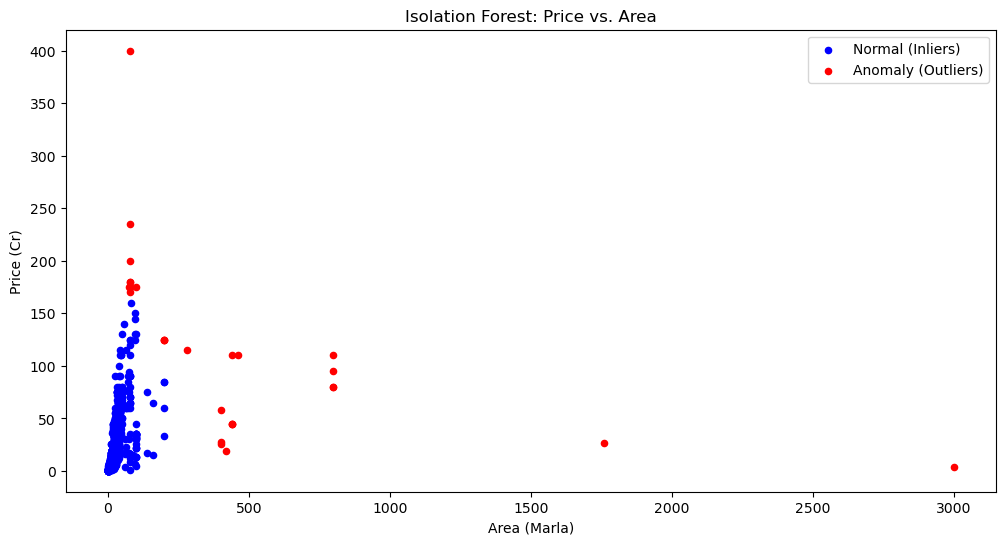

In [17]:
clf = IsolationForest(max_samples=500,contamination=0.01)
clf.fit(df[['Price(Cr)','Area(Marla)']])
y_pred = clf.predict(df[['Price(Cr)','Area(Marla)']])

# Creating the boolean mask (-1 means outlier, 1 means inlier)
is_outlier = y_pred == -1

plt.figure(figsize=(12, 6))

plt.scatter(x=df.loc[~is_outlier, 'Area(Marla)'], y=df.loc[~is_outlier, 'Price(Cr)'], 
            s=20, color='blue', label='Normal (Inliers)')

plt.scatter(x=df.loc[is_outlier, 'Area(Marla)'], y=df.loc[is_outlier, 'Price(Cr)'], 
            s=20, color='red', label='Anomaly (Outliers)')


plt.title('Isolation Forest: Price vs. Area')
plt.xlabel('Area (Marla)')
plt.ylabel('Price (Cr)')
plt.legend()
plt.show()

In [18]:
# Returns outliers rows
df.loc[is_outlier].shape

(29, 40)

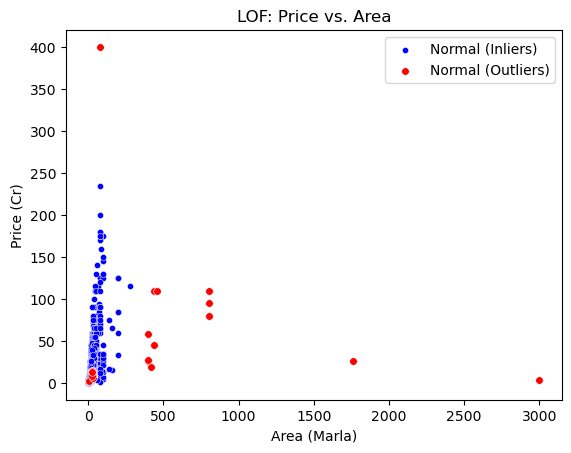

In [19]:
# Local Outlier Factor

from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=50,n_jobs=-1,contamination=0.01)
y_pred = lof.fit_predict(df[['Price(Cr)','Area(Marla)']])

is_outlier_lof = y_pred == -1

sns.scatterplot(data=df.loc[~is_outlier_lof],x='Area(Marla)',y='Price(Cr)',
               s=20,color='b', label='Normal (Inliers)')

sns.scatterplot(data=df.loc[is_outlier_lof],x='Area(Marla)',y='Price(Cr)',
               s=30,color='r',  label='Normal (Outliers)')

plt.title('LOF: Price vs. Area')
plt.xlabel('Area (Marla)')
plt.ylabel('Price (Cr)')
plt.legend()
plt.show()

*Removing the Outliers and visualizing the effect*

Text(0.5, 1.0, 'LOF')

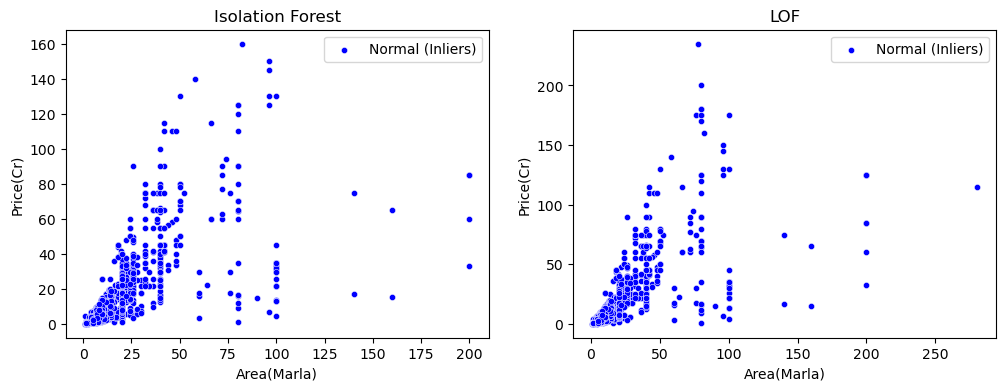

In [20]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(12,4))

sns.scatterplot(x=df.loc[~is_outlier, 'Area(Marla)'], y=df.loc[~is_outlier, 'Price(Cr)'], 
            s=20, color='blue', label='Normal (Inliers)',ax=ax[0])
ax[0].set_title("Isolation Forest")


sns.scatterplot(x=df.loc[~is_outlier_lof, 'Area(Marla)'], y=df.loc[~is_outlier_lof, 'Price(Cr)'], 
            s=20, color='blue', label='Normal (Inliers)',ax=ax[1])
ax[1].set_title("LOF")

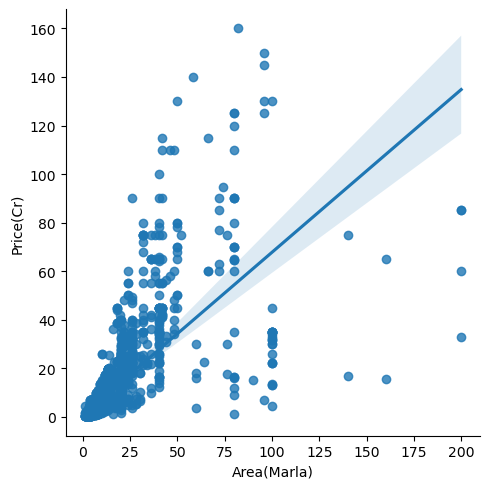

In [21]:
sns.lmplot(data=df.loc[~is_outlier],x='Area(Marla)',y='Price(Cr)')

### Obervations 
- Isolation Forest is proving better results since the data is not dense.
- The relations ship between Area and Price is kind of Linear (excluding Outliers)

## Type vs Area(Marla)

<Axes: xlabel='Type', ylabel='Area(Marla)'>

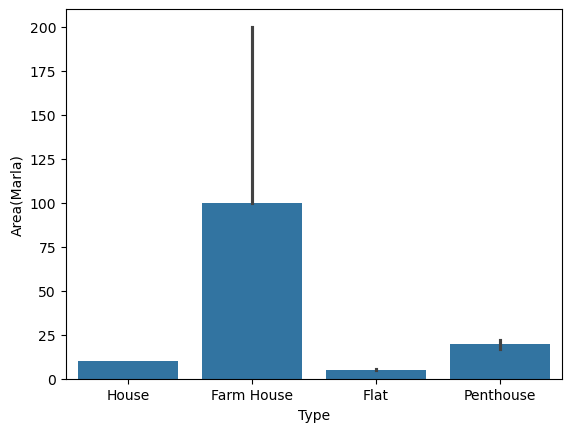

In [22]:
sns.barplot(x=df['Type'],y=df['Area(Marla)'],estimator=np.median)

<Axes: xlabel='Type', ylabel='Area(Marla)'>

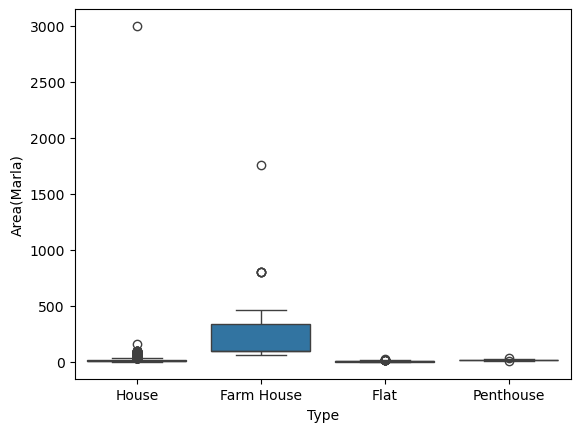

In [23]:
sns.boxplot(data =df,x='Type',y='Area(Marla)')

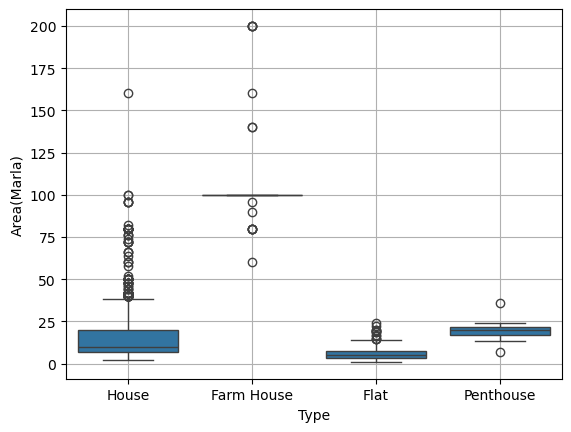

In [24]:
sns.boxplot(data =df.loc[~is_outlier] ,x='Type',y='Area(Marla)')
plt.grid();

## Bath(s) & Bedroom(s) vs Price

<Axes: xlabel='Bath(s)', ylabel='Price(Cr)'>

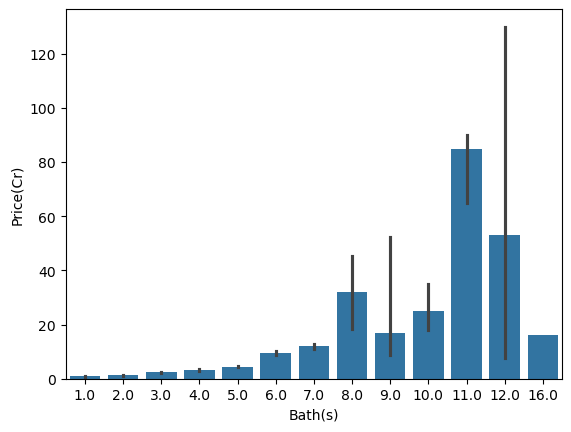

In [25]:
sns.barplot(x=df['Bath(s)'],y=df['Price(Cr)'],estimator=np.median)

<Axes: xlabel='Bedroom(s)', ylabel='Price(Cr)'>

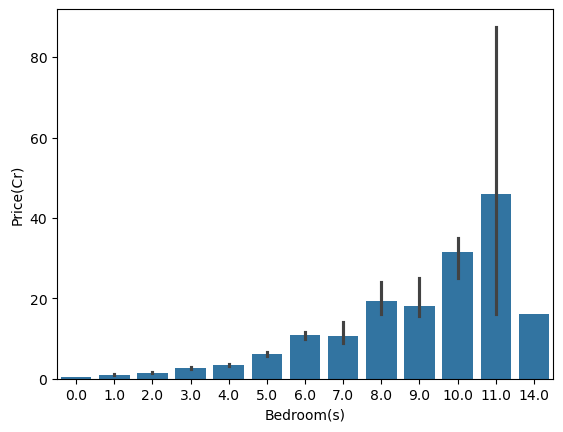

In [26]:
sns.barplot(x=df['Bedroom(s)'],y=df['Price(Cr)'],estimator=np.median)

### Observations 
- As the Bedrooms and Bathrooms increase so does the price.
- The last value of Bedrooms and Bathsrooms suggest an Outliers behaviour.

## Type vs Bedroom(s) & Bath(s)

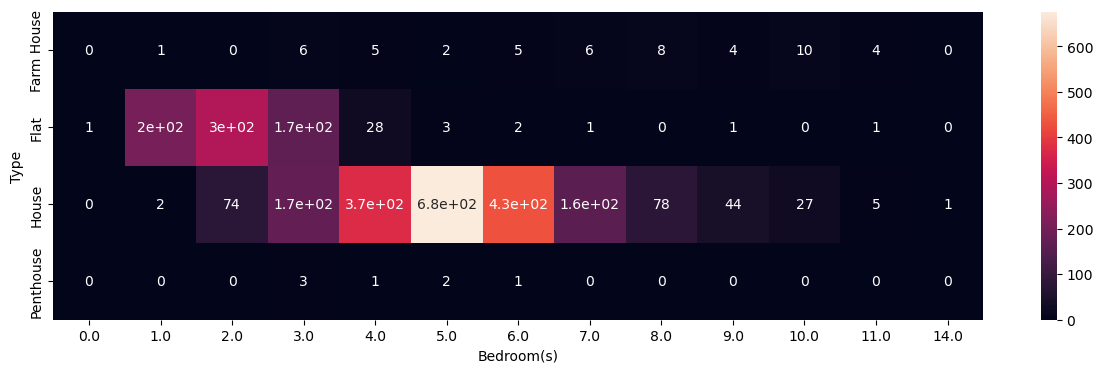

In [27]:
plt.figure(figsize=(15,4))
sns.heatmap(pd.crosstab(df['Type'],columns=df['Bedroom(s)']),annot=True);

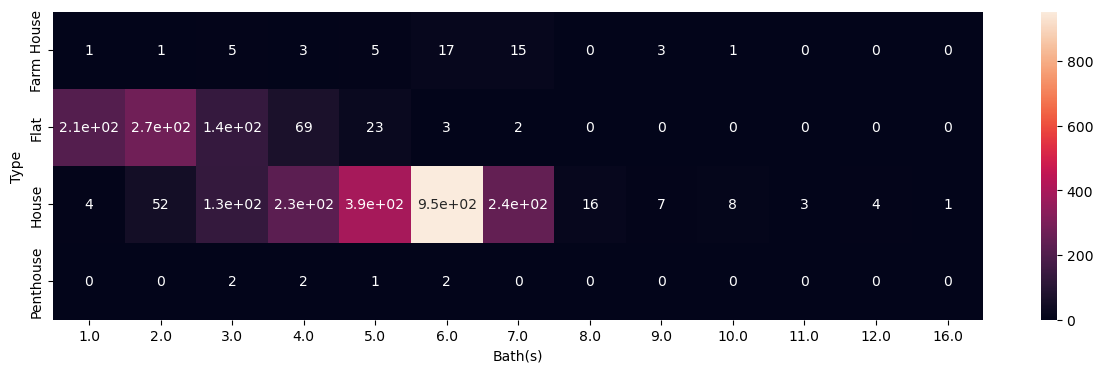

In [28]:
plt.figure(figsize=(15,4))
sns.heatmap(pd.crosstab(df['Type'],columns=df['Bath(s)']),annot=True);

## Observations
- **Bedrooms in Flats:** Common range is 1 - 3/4
- **Bedrooms in Houses:** Common range is 3 - 7
<br>

- **Bathrooms in Flats:** Common range is  1 -3
- **Bathrooms in Houses:** Common range is 2 - 7

## Location vs Price & Type

**Not done untill the correct data arrives**

Text(0.5, 1.0, 'Corner House')

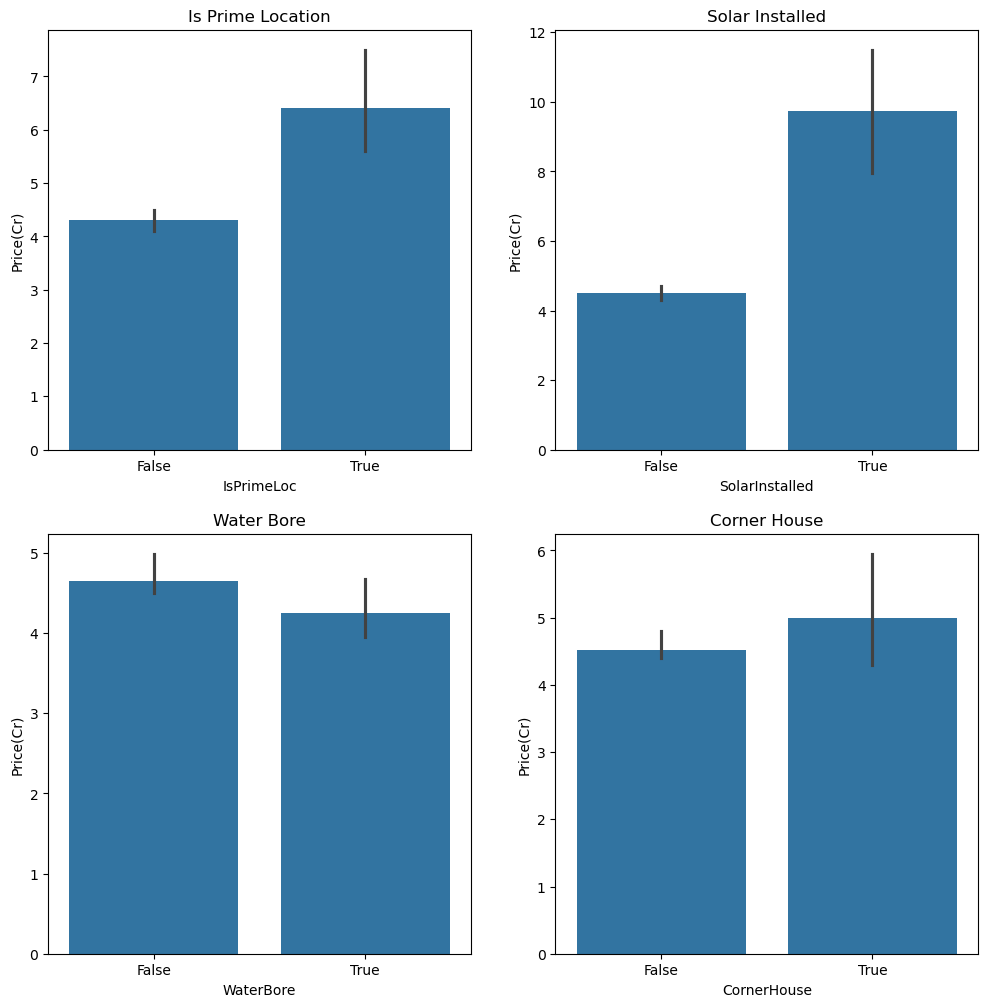

In [29]:
columns = ['IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse']

fig , axes = plt.subplots(2,2,figsize=(12,12))

sns.barplot(x=df['IsPrimeLoc'],y=df['Price(Cr)'],estimator=np.median,ax=axes[0][0])
axes[0][0].set_title('Is Prime Location')

sns.barplot(x=df['SolarInstalled'],y=df['Price(Cr)'],estimator=np.median,ax=axes[0][1])
axes[0][1].set_title('Solar Installed')

sns.barplot(x=df['WaterBore'],y=df['Price(Cr)'],estimator=np.median,ax=axes[1][0])
axes[1][0].set_title('Water Bore')

sns.barplot(x=df['CornerHouse'],y=df['Price(Cr)'],estimator=np.median,ax=axes[1][1])
axes[1][1].set_title('Corner House')

 - *Corner House, Prime Location, Solar Panels Installed influcence Price, while Water Boring doesn't*

## Luxury type

<Axes: xlabel='luxury_type', ylabel='Price(Cr)'>

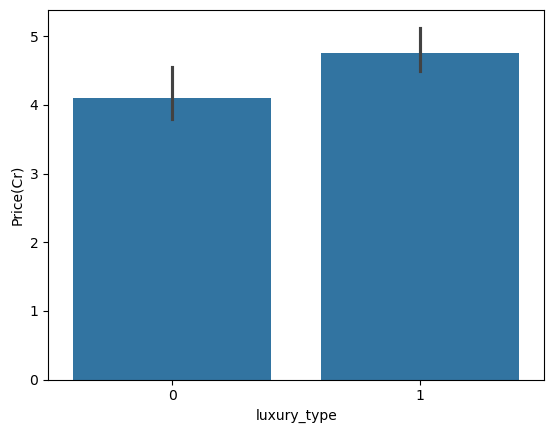

In [30]:
sns.barplot(x=df['luxury_type'],y=df['Price(Cr)'],estimator=np.median)

<Axes: xlabel='luxury_type', ylabel='Price(Cr)'>

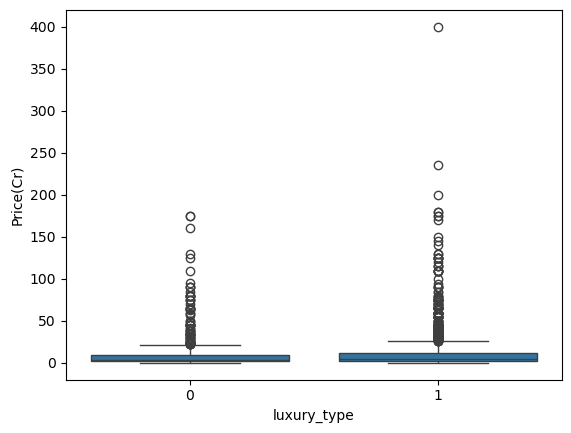

In [31]:
sns.boxplot(x=df['luxury_type'],y=df['Price(Cr)'])

### Observations 
- luxury type = 1 seems to have a greater Median of Price

## Built in Year

In [32]:
df[df['Built in year']<1900]['Built in year'].value_counts()

Built in year
0.0       502
1.0       178
2.0        15
3.0         7
5.0         7
4.0         4
10.0        4
7.0         2
8.0         2
225.0       2
15.0        1
40.0        1
205.0       1
21.0        1
1898.0      1
6.0         1
Name: count, dtype: int64

In [33]:
df.columns

Index(['Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)', 'Bedroom(s)', 'Location',
       'Description', 'Amenities: Main Features', 'Amenities: Rooms',
       'Amenities: Business and Communication',
       'Amenities: Community Features', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Bedrooms', 'Bathrooms',
       'Servant Quarters', 'Kitchens', 'Store Rooms',
       'Community Swimming Pool', 'Community Gym', 'Swimming Pool', 'Sauna',
       'Jacuzzi', 'Security Staff', 'Maintenance Staff',
       'Facilities for Disabled', 'Laundry or Dry Cleaning Facility',
       'Communal/Shared Kitchen', 'Storey Unit'],
      dtype='str')

## 'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators'

<Axes: xlabel='Parking Spaces', ylabel='Price(Cr)'>

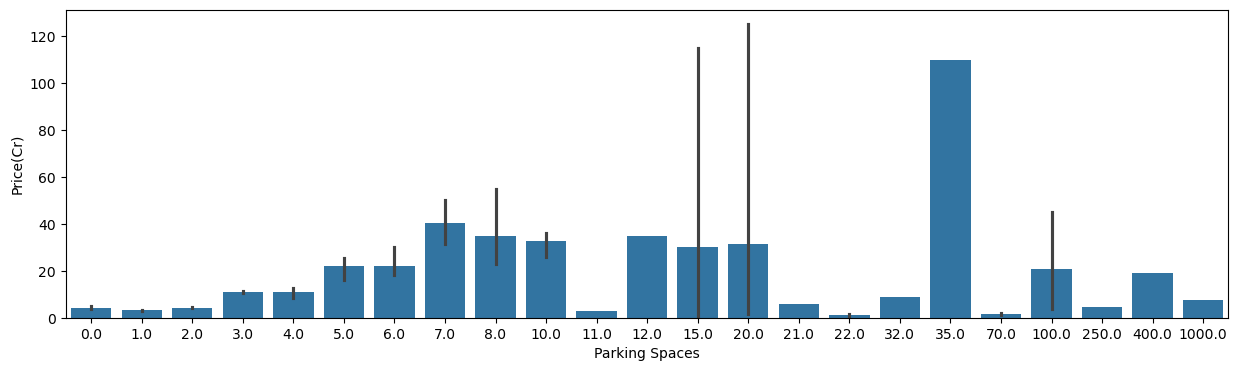

In [34]:
plt.figure(figsize=(15,4))
sns.barplot(x=df['Parking Spaces'],y=df['Price(Cr)'],estimator=np.median)

<Axes: xlabel='Floor', ylabel='Price(Cr)'>

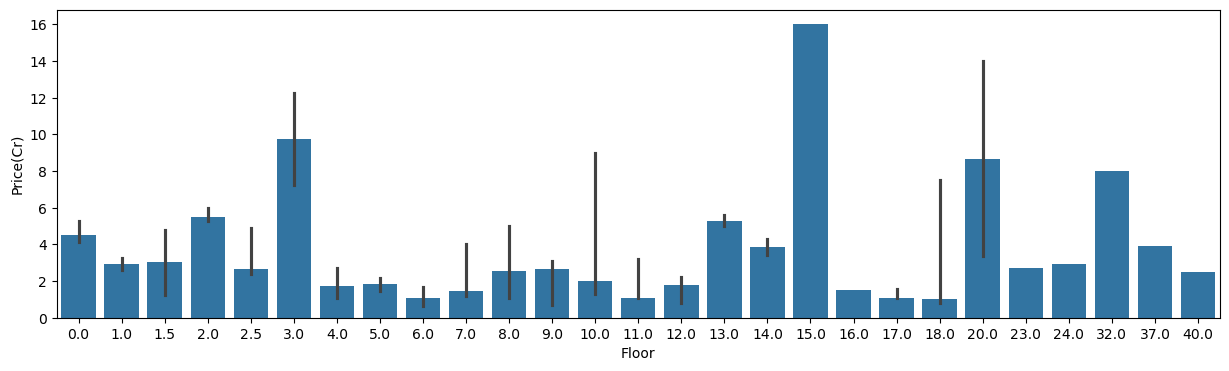

In [35]:
plt.figure(figsize=(15,4))
sns.barplot(x=df['Floor'],y=df['Price(Cr)'],estimator=np.median)

<Axes: xlabel='Elevators', ylabel='Price(Cr)'>

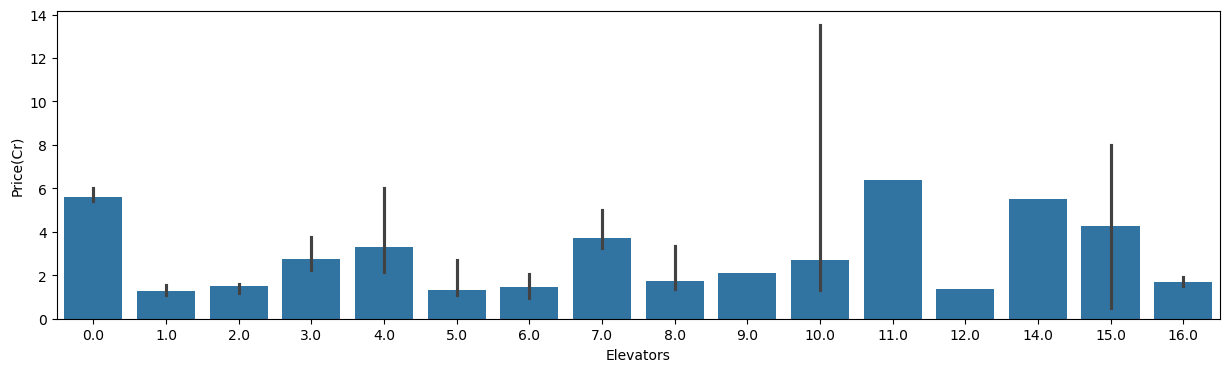

In [36]:
plt.figure(figsize=(15,4))
sns.barplot(x=df['Elevators'],y=df['Price(Cr)'],estimator=np.median)

## Servant Quarters

<Axes: xlabel='Servant Quarters', ylabel='Price(Cr)'>

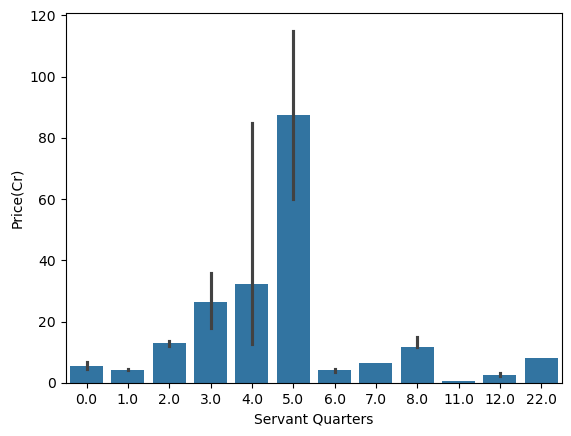

In [37]:
# plt.figure(figsize=(15,4))
sns.barplot(x=df['Servant Quarters'],y=df['Price(Cr)'],estimator=np.median)

## Kitchens

<Axes: xlabel='Kitchens', ylabel='Price(Cr)'>

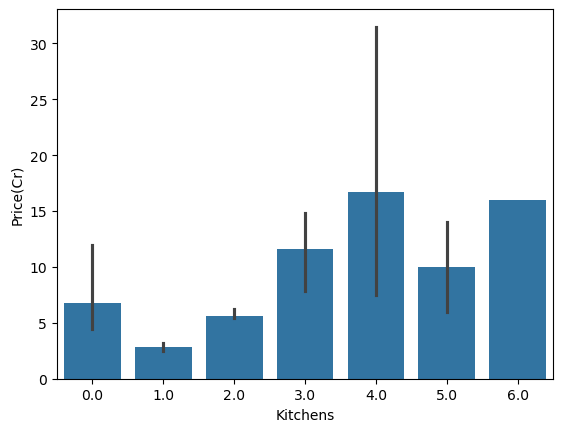

In [38]:
# plt.figure(figsize=(15,4))
sns.barplot(x=df['Kitchens'],y=df['Price(Cr)'],estimator=np.median)

<Axes: xlabel='Kitchens', ylabel='Price(Cr)'>

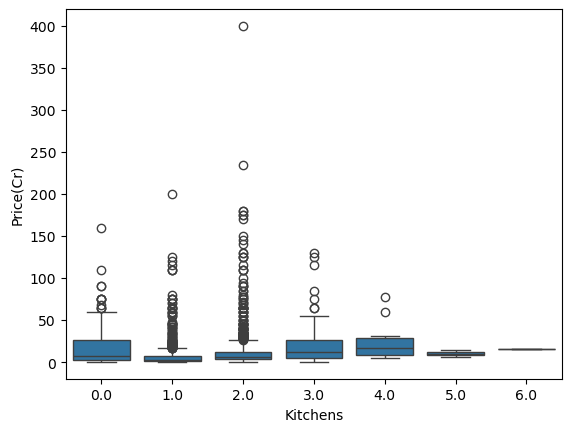

In [39]:
sns.boxplot(x=df['Kitchens'],y=df['Price(Cr)'])

## Store Rooms

<Axes: xlabel='Store Rooms', ylabel='Price(Cr)'>

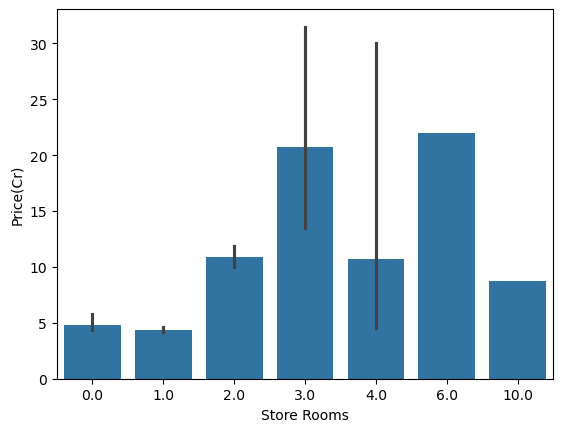

In [40]:
sns.barplot(x=df['Store Rooms'],y=df['Price(Cr)'],estimator=np.median)

## Storey Unit

<Axes: xlabel='Storey Unit', ylabel='Price(Cr)'>

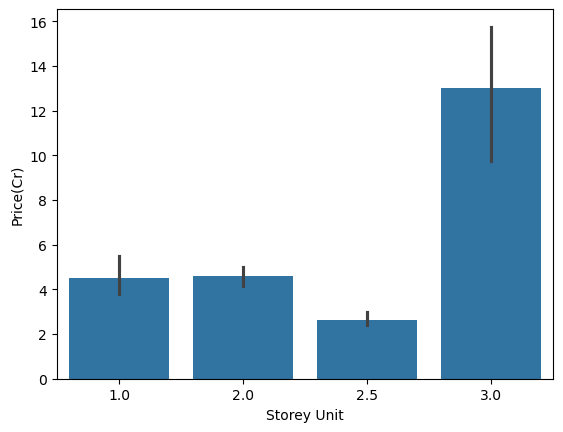

In [41]:
sns.barplot(x=df['Storey Unit'],y=df['Price(Cr)'],estimator=np.median)

### Observations
- Kitchens, Store Rooms, Servant Quarters doesn't seem to have any influence on Price.
- Storey Unit = 3 tends to have a greater Price.

In [42]:
df.columns

Index(['Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)', 'Bedroom(s)', 'Location',
       'Description', 'Amenities: Main Features', 'Amenities: Rooms',
       'Amenities: Business and Communication',
       'Amenities: Community Features', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Bedrooms', 'Bathrooms',
       'Servant Quarters', 'Kitchens', 'Store Rooms',
       'Community Swimming Pool', 'Community Gym', 'Swimming Pool', 'Sauna',
       'Jacuzzi', 'Security Staff', 'Maintenance Staff',
       'Facilities for Disabled', 'Laundry or Dry Cleaning Facility',
       'Communal/Shared Kitchen', 'Storey Unit'],
      dtype='str')

<Axes: xlabel='Swimming Pool', ylabel='Price(Cr)'>

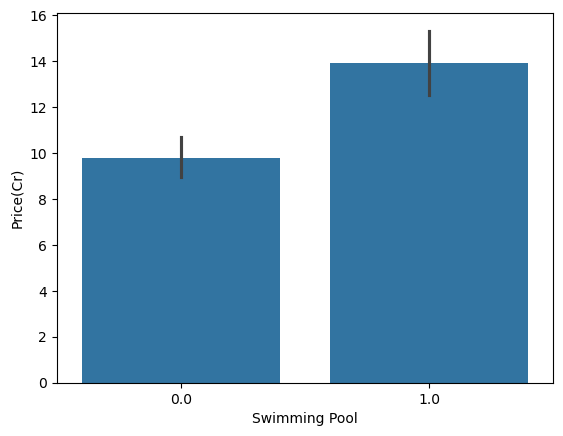

In [43]:
sns.barplot(data=df.fillna(0),x='Swimming Pool',y='Price(Cr)')

<Axes: xlabel='Communal/Shared Kitchen', ylabel='Price(Cr)'>

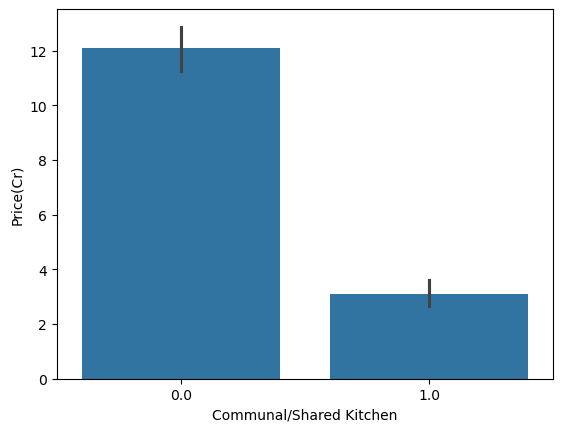

In [44]:
sns.barplot(data=df.fillna(0),x='Communal/Shared Kitchen',y='Price(Cr)')

<Axes: xlabel='Community Swimming Pool', ylabel='Price(Cr)'>

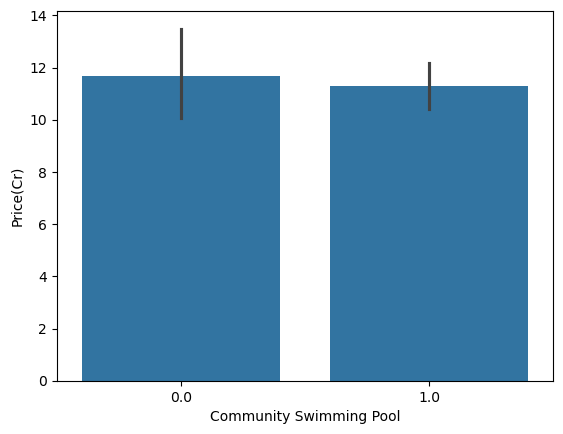

In [45]:
sns.barplot(data=df.fillna(0),x='Community Swimming Pool',y='Price(Cr)')

## Change of Strategy
1. Removing Farm Houses (b/c our end goal is Price Predictor for Houses and Flats, inlcuding Farm Houses would have a negative effect on our Predictive Model)
2. Making a separate dataset for Flats since Flats have its own features which are not present in Houses
3. And merging Penthouse with Flats

In [48]:
df['Type'].value_counts()

Type
House         2080
Flat           720
Farm House      55
Penthouse       10
Name: count, dtype: int64

In [49]:
df = df[df['Type']!= 'Farm House']

In [51]:
flats = df[df['Type']!='House']

In [52]:
flats.shape

(730, 40)

In [53]:
houses = df[df['Type']=='House']

In [54]:
houses.shape

(2080, 40)

In [57]:
# Saving files

flats.to_csv('flats.csv')
houses.to_csv('houses.csv')